In [1]:
import numpy as np #numpy version 1.26.4
import os
import matplotlib.pyplot as plt #matplotlib version 3.7.3
import scipy as sp #scipy version 1.12.0
import scipy.ndimage #scipy version 1.12.0
import json
import skimage.io  #scikit-image version 0.22.0

toppath = '/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem'
processing_dict_path = os.path.join(toppath, 'processing_data.json')

In [2]:
processing_dict = json.load(open(processing_dict_path,'r'))

In [3]:
# function to load nanotom vol file
# path = "/mnt/nas_nanotomData/CT_Data_PSI/FR54/2022_10_03_cell007_test_after_op/2022_10_03_cell007_test_after_op_.vol"   #the .vol file path

def load_nanotom(path, pcrSizeX = 0, pcrSizeY = 0, pcrSizeZ = 0):
    
    if pcrSizeX == 0 or pcrSizeY == 0 or pcrSizeZ == 0:
        print('searching pcr file for image dimensions')
    
        pcrpath = path.split('.')[0]+'.pcr'
        
        if not os.path.exists(pcrpath):
            print('pcr-file not found, please provide image dimensions manually')
        else:
            with open(pcrpath) as file:
                lines = file.readlines()
                
            for line in lines:
                splitline = line.split('=')
                if splitline[0] == 'ROI_SizeX':
                    pcrSizeX = int(splitline[1])
                if splitline[0] == 'ROI_SizeY':
                    pcrSizeY = int(splitline[1])
                if splitline[0] == 'ROI_SizeZ':
                    pcrSizeZ = int(splitline[1])
                    
    else:
        print('dimension manually provided as '+str(pcrSizeX)+'x'+str(pcrSizeY)+'x'+str(pcrSizeZ))
        
    print('dimensions considered as '+str(pcrSizeX)+'x'+str(pcrSizeY)+'x'+str(pcrSizeZ))
    
    print('load the file')
    
    with open(path,'r') as file:
        file.seek(0)
        im = np.fromfile(file, dtype='<f4').reshape(pcrSizeX,pcrSizeY,pcrSizeZ, order ='F')
        
    return im    

In [4]:
def testrotation(testim, angle):
    plt.figure(figsize=(12,12))
    testrot = sp.ndimage.rotate(testim, angle)
    plt.imshow(testrot, vmin=vmin, vmax=vmax)
    spacing = 25
    grid_0 = np.arange(0,testrot.shape[0],spacing)
    grid_1 = np.arange(0,testrot.shape[1],spacing)
    plt.hlines(grid_0, 0, testrot.shape[1]-1, 'w', linewidth = 0.5)
    plt.vlines(grid_1, 0, testrot.shape[0]-1, 'w', linewidth = 0.5)

In [5]:
def rotate_im(im, angle1, angle2, angle3):
    if np.abs(angle1)>0.25:
        im = sp.ndimage.rotate(im, angle1)
    if np.abs(angle2)>0.25:
        im = sp.ndimage.rotate(im, angle2, axes=(2,0))
    if np.abs(angle3)>0.25:
        im = sp.ndimage.rotate(im, angle3, axes=(2,1))
    return im

In [6]:
def create_grid(im,ax, spacing = 50):
    grid_0 = np.arange(0,im.shape[0]-spacing,spacing)
    grid_1 = np.arange(0,im.shape[1]-spacing,spacing)
    ax.hlines(grid_0, 0, im.shape[1]-1, 'w', linewidth = 0.5)
    ax.vlines(grid_1, 0, im.shape[0]-1, 'w', linewidth = 0.5)

In [7]:
vmin = -0.0587
vmax = 0.3144

In [8]:
series = 'D'
sample = '1'

In [9]:
sample_path = os.path.join(toppath, series+'_series', series+'_'+sample)

In [10]:
preoppath = os.path.join(sample_path , series+'_'+sample+'_preop', series+'_'+sample+'_preop_.vol')
# preoppath = os.path.join(sample_path , series+'_'+sample+'_dryc', series+'_'+sample+'_dryc_.vol')
preopim = load_nanotom(preoppath)

searching pcr file for image dimensions
dimensions considered as 362x784x1607
load the file


In [12]:
postop1path = os.path.join(sample_path , series+'_'+sample+'_postop_1', series+'_'+sample+'_postop_1_.vol')
postop1path = os.path.join(sample_path , series+'_'+sample+'_postop1', series+'_'+sample+'_postop1_.vol')
postop1im = load_nanotom(postop1path)

searching pcr file for image dimensions
dimensions considered as 347x809x1565
load the file


In [13]:
postop2path = os.path.join(sample_path, series+'_'+sample+'_postop_2', series+'_'+sample+'_postop_2_.vol')
postop2path = os.path.join(sample_path, series+'_'+sample+'_postop2', series+'_'+sample+'_postop2_.vol')
postop2im = load_nanotom(postop2path)

searching pcr file for image dimensions
dimensions considered as 385x794x1493
load the file


In [14]:
# extrapath = os.path.join(sample_path, series+'_'+sample+'_dry_40C', series+'_'+sample+'_dry_40C_.vol')
# postop2path = os.path.join(sample_path, series+'_'+sample+'_postop_2b', series+'_'+sample+'_postop_2b_.vol')
# extraim = load_nanotom(extrapath)

In [16]:
processing_dict[series+'_'+sample]['rotangles']

{'preop': [1, 0, -1], 'postop_1': [0.5, -0.5, -1.75], 'postop_2': [0, 0, -0.9]}

In [37]:
im = postop1im
stage = 'postop_1'
# stage = 'liquid_wet_wet'
angle1 = 0.5
angle2 = -0.5
angle3 = -1.75

# angles = {
#     'preop': (2.3 , -1 , 1), #(0,0,0)
#     'postop_1': (1.9 , 0 , 1),
#     'postop_2': (0,0,0)}

# angles = {
#     'liquid_wet_wet': (1 , 0 , 0),
#     'wet2': (0 , 0 , 0),
#     'wet': (-1 , -0.3 , 0),
#     'liquid_wet_moist_air': (-1 , 0 , 0),
#     'liquid_wet': (0.5 , -0.3 , 0),
#     'dry': (-1 , 0.3 , 0.6)}

print(angle1,',',angle2,',',angle3)

0.5 , -0.5 , -1.75


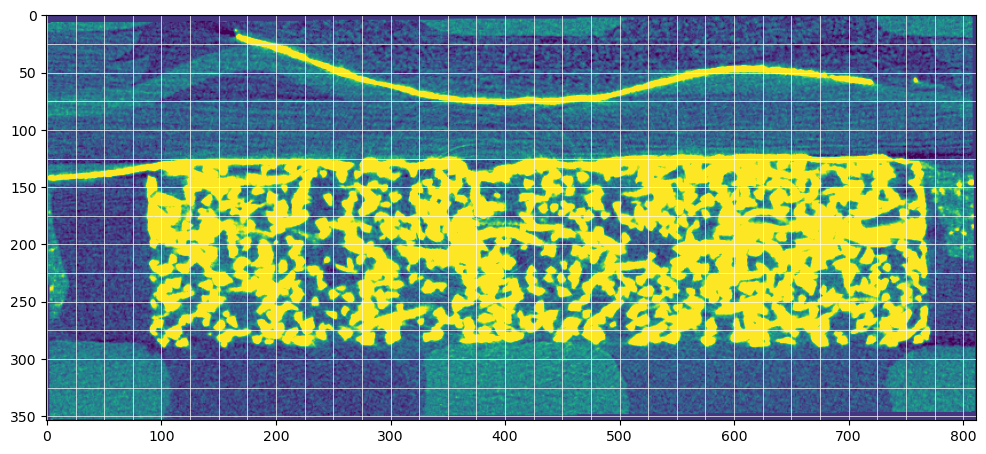

In [38]:
testrotation(im[:,:,800], angle1)

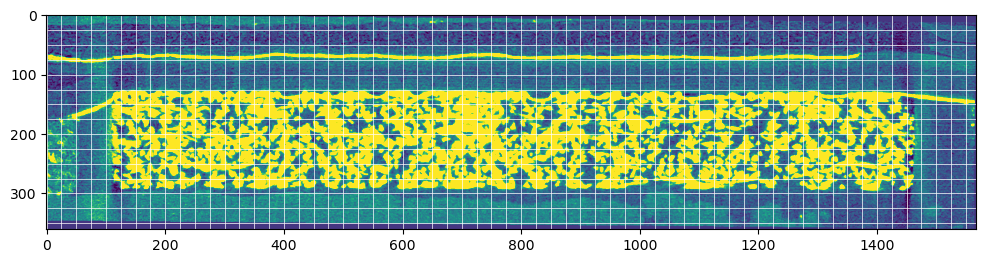

In [39]:
testrotation(im[:,500,:], angle2)

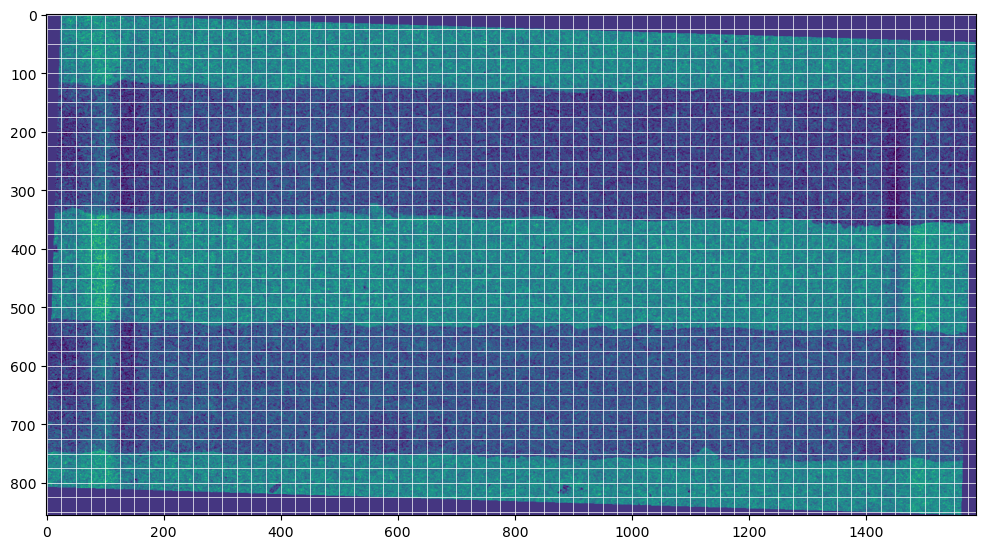

In [40]:
testrotation(im[-1,:,:], angle3)

In [41]:
im = rotate_im(im, angle1, angle2, angle3)

In [42]:
processing_dict[series+'_'+sample]['cropping']

{'preop': [40, 170, 60, 760, 120, 1420],
 'postop_1': [30, 160, 90, 790, 100, 1400],
 'postop_2': [50, 180, 80, 780, 100, 1400]}

In [43]:
crops = processing_dict[series+'_'+sample]['cropping']

# crops = {
#     'preop': (50 , 180 , 110 , 810 , 150 , 1450),   #0 , -1 , 0 , -1  , 0 , -1
#     'postop_1': (40 , 170 , 95 , 795 , 150 , 1450),
#     'postop_2': (0 , -1 , 0 , -1  , 0 , -1)}

# crops = {
#     'liquid_wet_wet': (60 , 160 , 20 , 720 , 450 , 1750),
#     'wet2': (70 , 170 , 70 , 770 , 450 , 1750),
#     'wet': (75 , 175 , 70 , 770 , 400 , 1700),
#     'dry':  (110 , 210 , 70 , 770 , 450 , 1750),
#     'liquid_wet': (60 , 160 , 80 , 780 , 400 , 1700),
#     'liquid_wet_moist_air': (80 , 180 , 90 , 790 , 450 , 1750)}

a,b,c,d,e,f = crops[stage]


a = 30
b = a+300   #+100 for Fumatech BPM, +130 for N115 CCM, 300 for registration
c = 105
d = c+700
e = 200
f = e + 1300

print(a,',',b,',',c,',',d,',',e,',',f)

30 , 330 , 105 , 805 , 200 , 1500


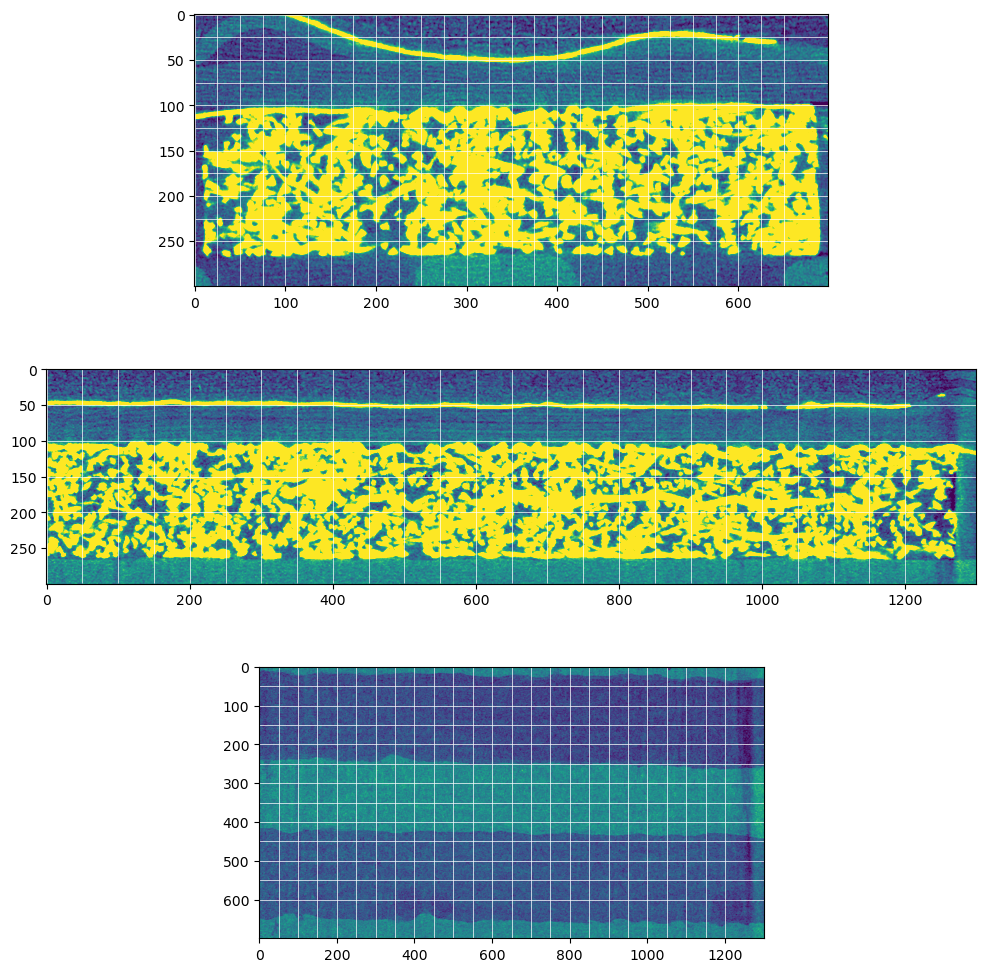

In [44]:
fig, axs = plt.subplots(3,1, figsize=(12,12))
im1 = im[a:b,c:d,600]
im2 = im[a:b,400,e:f]
im3 = im[-40,c:d,e:f]

axs[0].imshow(im1, vmin=vmin, vmax=vmax)
create_grid(im1,axs[0], spacing=25)
axs[1].imshow(im2, vmin=vmin, vmax=vmax)
create_grid(im2,axs[1])
axs[2].imshow(im3, vmin=vmin, vmax=vmax)
create_grid(im3,axs[2])


In [45]:
im3.shape

(700, 1300)

In [46]:
outim = im[a:b,c:d,e:f]

In [47]:
outim.shape

(300, 700, 1300)

In [48]:
outputpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_rotcrop_large.tif')
print(outputpath)

/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem/D_series/D_1/D_1_postop_1_rotcrop_large.tif


In [49]:
skimage.io.imsave(outputpath,np.transpose(outim,(2,1,0)))

In [50]:
processing_dict[series+'_'+sample] = {'rotangles': angles,
                           'cropping': crops}

NameError: name 'angles' is not defined

In [116]:
# with open(processing_dict_path, "w") as outfile:
    # json.dump(processing_dict, outfile,indent = 4)